In [73]:
%pip install -r constraints.txt

Note: you may need to restart the kernel to use updated packages.


# MRA

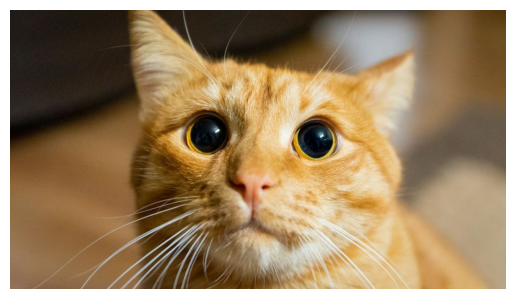

In [74]:
import cv2
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread("/Users/chibangnguyen/Documents/BigImage/public/orangecat.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [75]:
import pywt
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.cvtColor(cv2.imread("../public/Blackcat.jpg"), cv2.COLOR_BGR2RGB)

level = 10
factor = 2 ** level
h, w = img.shape[:2]
pad_h = (-h) % factor
pad_w = (-w) % factor
if pad_h or pad_w:
    img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode="edge")

coeffs = pywt.mra2(img, wavelet="haar", level=level,
                   transform="swt2", axes=(0, 1))

rows = len(coeffs)
plt.figure(figsize=(10, 2 * rows))
plt.subplot(rows, 1, 1)
plt.imshow(img)
plt.title('Original (padded)' if pad_h or pad_w else 'Original')

for i, c in enumerate(coeffs[1:], start=1):
    coeff_img = c
    if isinstance(coeff_img, tuple):
        coeff_img = sum((np.abs(comp) for comp in coeff_img))
    if coeff_img.ndim == 3 and coeff_img.shape[0] in (3, 4):
        coeff_img = np.transpose(coeff_img, (1, 2, 0))
    plt.subplot(rows, 1, i + 1)
    if coeff_img.ndim == 2:
        plt.imshow(coeff_img, cmap='gray')
    else:
        plt.imshow(coeff_img)
    plt.title(f'Level {i}')

plt.tight_layout()
plt.show()


KeyboardInterrupt: 